In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
from tqdm.notebook import tqdm
import seaborn as sns

from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from ibl_info.pcaprojections import analyze_neural_interaction, analyze_inter_region_interaction


%load_ext autoreload
%autoreload 2


In [2]:
import warnings

warnings.filterwarnings("ignore")
color = ["#FF4D4D", "#4D79FF"]

In [3]:
from scipy.stats import mannwhitneyu, ttest_ind

In [4]:
def plot_interaction_significance(results):
    # Extract interaction coefficients (index 2)
    interactions = results["all_bootstrap_coefficients"][:, 2]

    # Calculate 95% Confidence Interval
    ci_lower = np.percentile(interactions, 2.5)
    ci_upper = np.percentile(interactions, 97.5)
    mean_val = np.mean(interactions)

    # Check significance
    is_significant = (ci_lower > 0) or (ci_upper < 0)

    # Visualization
    plt.figure(figsize=(8, 5))
    plt.hist(interactions, bins=20, alpha=0.7, color="purple", edgecolor="black")
    plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero")
    plt.axvline(mean_val, color="black", linewidth=2, label=f"Mean: {mean_val:.2f}")
    plt.axvline(ci_lower, color="gray", linestyle=":", label="95% CI")
    plt.axvline(ci_upper, color="gray", linestyle=":")

    plt.title(f"Interaction Significance (Significant: {is_significant})")
    plt.xlabel("Standardized Interaction Coefficient")
    plt.ylabel("Bootstrap Count")
    plt.legend()
    plt.show()

In [5]:
def plot_coefficient_comparison(results):
    # Shape: (n_bootstraps, 3) -> [PC1, PC2, Interaction]
    coefs = results["all_bootstrap_coefficients"]

    plt.figure(figsize=(8, 6))
    plt.boxplot(
        [coefs[:, 0], coefs[:, 1], coefs[:, 2]],
        labels=["Subset 1 (Main)", "Subset 2 (Main)", "Interaction"],
    )

    plt.axhline(0, color="gray", linestyle="--")
    plt.ylabel("Standardized Log-Odds Contribution")
    plt.title("Relative Importance of Neural Terms")

    # Calculate Synergy Ratio
    # |Interaction| / (|Main1| + |Main2|)
    synergy_ratio = np.abs(coefs[:, 2]) / (np.abs(coefs[:, 0]) + np.abs(coefs[:, 1]))
    print(f"Average Synergy Ratio: {np.mean(synergy_ratio):.2f}")
    print("(>1.0 implies interaction dominates main effects)")
    plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

In [7]:
filename = "../data/generated/pcadecoders/stim/selective_decomposition_ACAd_stim_lineardecoder_goodsessions.pkl"

with open(filename, "rb") as f:
    data_region = pkl.load(f)

In [8]:
def create_pooled_data(data_region, region_name):

    # 1. Initialize containers to store the pooled data
    # We use a list of dictionaries to easily convert to a DataFrame later
    pooled_data = []

    # 2. Iterate through each animal in the region dictionary
    for animal_name, animal_data in data_region.items():
        for condition in ["congruent", "incongruent"]:

            # A. Get arrays
            # Shape: (n_bootstraps, 3)
            boot_coeffs = np.array(animal_data[condition]["all_bootstrap_coefficients"])
            # Shape: (n_bootstraps,)
            boot_accs = np.array(animal_data[condition]["all_bootstrap_test_accuracy"])

            # B. Create Mask (Accuracy > 0.5)
            valid_mask = boot_accs > 0.5

            # C. Filter
            # valid_coeffs will still be 2D: (n_valid_samples, 3)
            valid_coeffs = boot_coeffs[valid_mask]

            # D. Check if we have data left after filtering
            if len(valid_coeffs) == 0:
                continue

            # E. Store data in "Long Format"
            # We iterate through the 3 columns (coefficient indices)
            for coeff_idx in range(valid_coeffs.shape[1]):
                # Extract the column for this specific coefficient index
                specific_coeffs = valid_coeffs[:, coeff_idx]

                # Create a temporary DataFrame for efficient appending
                temp_df = pd.DataFrame(
                    {
                        "Animal": animal_name,
                        "Condition": condition,
                        "Coeff_ID": f"Coeff_{coeff_idx}",  # Labels: Coeff_0, Coeff_1, Coeff_2
                        "Value": specific_coeffs,
                    }
                )

                pooled_data.append(temp_df)
    df = pd.concat(pooled_data, ignore_index=True)

    # plt.figure(figsize=(12, 6))

    # sns.violinplot(
    #     data=df,
    #     x="Coeff_ID",
    #     y="Value",
    #     hue="Condition",
    #     split=True,  # Split the violin to save space and compare directly
    #     inner="quartile",
    #     palette="muted",
    # )

    # plt.title(f"{region_name}")
    # plt.ylabel("Coefficient Value")
    # plt.grid(True, axis="y", alpha=0.3)
    # plt.show()

    # Loop through each coefficient type (0, 1, 2) to test them individually
    # for coeff_id in sorted(df["Coeff_ID"].unique()):
    #     subset = df[df["Coeff_ID"] == coeff_id]

    #     # Split into two arrays
    #     cong_vals = subset[subset["Condition"] == "congruent"]["Value"]
    #     inc_vals = subset[subset["Condition"] == "incongruent"]["Value"]

    #     # Run Stats (Mann-Whitney U test is safer for non-normal distributions)
    #     # If you prefer standard T-test, use stats.ttest_ind
    #     stat, p_val = mannwhitneyu(cong_vals, inc_vals, alternative="two-sided")

    #     # Calculate means for display
    #     mean_cong = cong_vals.mean()
    #     mean_inc = inc_vals.mean()

    #     # Significance marker
    #     sig = "*" if p_val < 0.05 else "ns"
    #     if p_val < 0.001:
    #         sig = "***"

    # print(
    #     f"{region_name}|{coeff_id:<10} | {mean_cong:<12.4f} | {mean_inc:<12.4f} | {p_val:.2e}   | {sig}"
    # )

    return df

In [9]:
from glob import glob
from scipy.stats import wilcoxon

In [48]:
def given_region_coeff_statistics(data_region, region, plotting=True):
    congruent_coeffs_means = []
    incongruent_coeffs_means = []

    congruent_coeffs_stds = []
    incongruent_coeffs_stds = []

    congruent_explained_var = []
    incongruent_explained_var = []

    for animal in data_region.keys():
        congruent_coeffs_means.append(
            list(data_region[animal]["congruent"]["mean_coefficients"].values())
        )
        incongruent_coeffs_means.append(
            list(data_region[animal]["incongruent"]["mean_coefficients"].values())
        )

        congruent_coeffs_stds.append(
            list(data_region[animal]["congruent"]["std_coefficients"].values())
        )
        incongruent_coeffs_stds.append(
            list(data_region[animal]["incongruent"]["std_coefficients"].values())
        )
        congruent_explained_var.append(
            list(data_region[animal]["congruent"]["mean_explained_variance"].values())
        )
        incongruent_explained_var.append(
            list(data_region[animal]["incongruent"]["mean_explained_variance"].values())
        )

    congruent_coeffs_means = np.asarray(congruent_coeffs_means)
    incongruent_coeffs_means = np.asarray(incongruent_coeffs_means)
    congruent_coeffs_stds = np.asarray(congruent_coeffs_stds)
    incongruent_coeffs_stds = np.asarray(incongruent_coeffs_stds)

    congruent_explained_var = np.asarray(congruent_explained_var)
    incongruent_explained_var = np.asarray(incongruent_explained_var)

    sems_explained_var = [
        np.std(incongruent_explained_var) / np.sqrt(len(incongruent_explained_var)),
        np.std(congruent_explained_var) / np.sqrt(len(congruent_explained_var)),
    ]

    color = ["#FF4D4D", "#4D79FF"]

    sems = [
        np.std(incongruent_coeffs_means[:, 2]) / np.sqrt(len(incongruent_coeffs_means)),
        np.std(congruent_coeffs_means[:, 2]) / np.sqrt(len(congruent_coeffs_means)),
    ]

    if plotting:
        fig, ax = plt.subplots(figsize=(8, 4), ncols=2, sharex=True)
        ax[0].bar(
            np.arange(2),
            [np.mean(incongruent_coeffs_means[:, 2]), np.mean(congruent_coeffs_means[:, 2])],
            yerr=sems,
            color=color,
            edgecolor="k",
            alpha=0.75,
        )
        ax[0].set_xticks(np.arange(2), ["Incongruent", "Congruent"])
        ax[0].set_ylabel("Interaction coefficient")
        sns.despine()

        ax[1].bar(
            np.arange(2),
            [np.mean(incongruent_explained_var), np.mean(congruent_explained_var)],
            yerr=sems_explained_var,
            color=color,
            edgecolor="k",
            alpha=0.75,
        )
        ax[1].set_xticks(np.arange(2), ["Incongruent", "Congruent"])
        ax[1].set_ylabel("Explained Variance ")
        ax[1].set_ylim(0, 1)
        plt.suptitle(f"{region}")

    # return np.mean(incongruent_coeffs_means[:, 2]), np.mean(congruent_coeffs_means[:, 2]), sems
    return incongruent_coeffs_means, congruent_coeffs_means, sems

In [11]:
collate_means_choice = []
collate_sems_choice = []
files_choice = np.sort(glob("../data/generated/pcadecoders/choice/*.pkl"))
for filename in files_choice:
    with open(filename, "rb") as f:
        data_region = pkl.load(f)
    # region_name = filename.rsplit("_stim_")[0].rsplit("_decomposition_")[-1]
    region_name = filename.rsplit("_choice_")[0].rsplit("_decomposition_")[-1]
    icm, cm, sems = given_region_coeff_statistics(
        data_region=data_region, region=region_name, plotting=False
    )
    collate_means_choice.append([icm, cm])
    collate_sems_choice.append(sems)

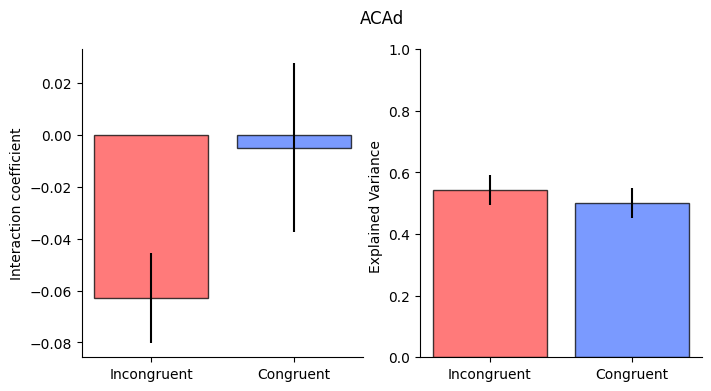

In [18]:
collate_means_stim = []
collate_sems_stim = []
region_names = []
files_stim = np.sort(glob("../data/generated/pcadecoders/stim/*.pkl"))
for filename in files_stim:
    with open(filename, "rb") as f:
        data_region = pkl.load(f)
    # region_name = filename.rsplit("_stim_")[0].rsplit("_decomposition_")[-1]
    region_name = filename.rsplit("_stim_")[0].rsplit("_decomposition_")[-1]
    icm, cm, sems = given_region_coeff_statistics(
        data_region=data_region, region=region_name, plotting=True
    )
    region_names.append(region_name)
    collate_means_stim.append([icm, cm])
    collate_sems_stim.append(sems)
    break

In [13]:
collate_means_choice = np.asarray(collate_means_choice)
collate_means_stim = np.asarray(collate_means_stim)

collate_sems_choice = np.asarray(collate_sems_choice)
collate_sems_stim = np.asarray(collate_sems_stim)

In [14]:
collate_sems_stim.shape

(25, 2)

Text(0, 0.5, 'Interaction coefficient')

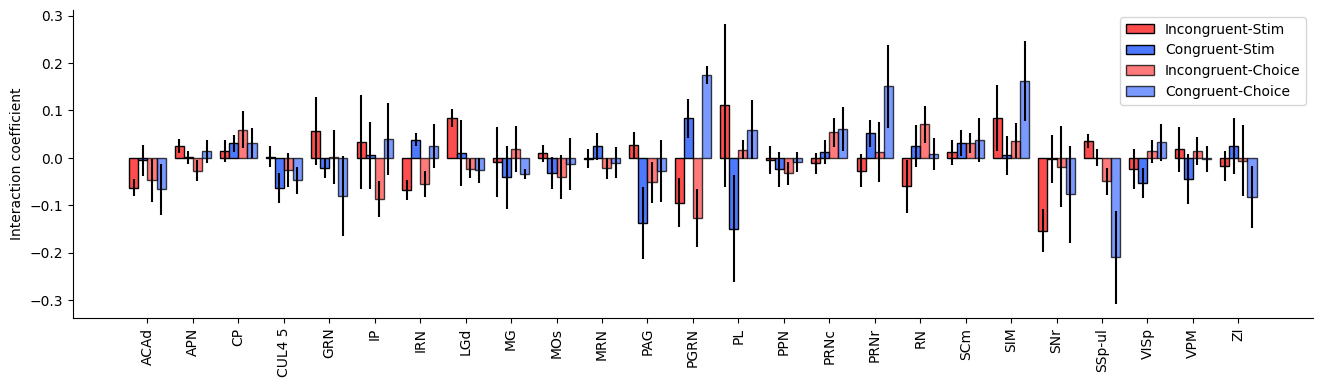

In [17]:
fig, ax = plt.subplots(figsize=(16, 4))
width = 0.2
xticks = np.arange(len(collate_means_choice))
ax.bar(
    xticks - 1.5 * width,
    collate_means_stim[:, 0],
    color=color[0],
    edgecolor="k",
    width=width,
    label="Incongruent-Stim",
    yerr=collate_sems_stim[:, 0],
)
ax.bar(
    xticks - 0.5 * width,
    collate_means_stim[:, 1],
    color=color[1],
    edgecolor="k",
    width=width,
    label="Congruent-Stim",
    yerr=collate_sems_stim[:, 1],
)

ax.bar(
    xticks + 0.5 * width,
    collate_means_choice[:, 0],
    color=color[0],
    edgecolor="k",
    width=width,
    alpha=0.75,
    label="Incongruent-Choice",
    yerr=collate_sems_choice[:, 0],
)
ax.bar(
    xticks + 1.5 * width,
    collate_means_choice[:, 1],
    color=color[1],
    edgecolor="k",
    width=width,
    alpha=0.75,
    label="Congruent-Choice",
    yerr=collate_sems_choice[:, 1],
)
ax.set_xticks(xticks, region_names, rotation=90)
plt.legend()
sns.despine()
ax.set_ylabel("Interaction coefficient")

In [30]:
filename = "../data/generated/pcadecoders/stim/selective_decomposition_PAG_stim_lineardecoder_goodsessions.pkl"

with open(filename, "rb") as f:
    data_x = pkl.load(f)

In [31]:
mean_accuracies = []

for eid in data_x.keys():
    mean_accuracies.append(
        [
            data_x[eid]["incongruent"]["mean_test_accuracy"],
            data_x[eid]["congruent"]["mean_test_accuracy"],
        ]
    )

In [32]:
mean_accuracies = np.asarray(mean_accuracies)

Text(0, 0.5, 'Accuracy')

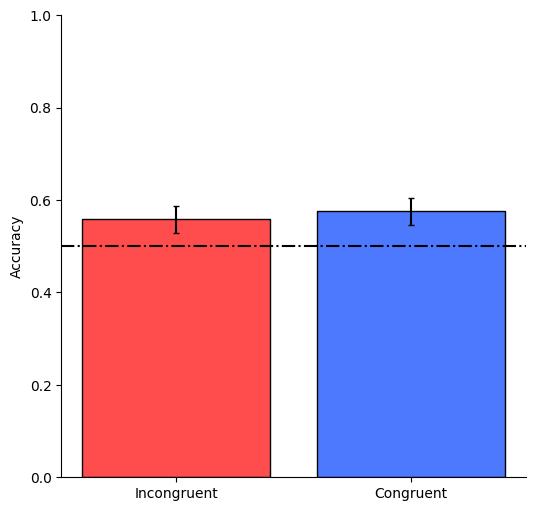

In [45]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.bar(
    np.arange(2),
    np.mean(mean_accuracies, axis=0),
    color=color,
    edgecolor="k",
    yerr=np.std(mean_accuracies) / np.sqrt(len(mean_accuracies)),
    capsize=2,
)
ax.set_ylim(0, 1)
ax.axhline(0.5, color="k", linestyle="-.")
sns.despine()
ax.set_xticks(np.arange(2), ["Incongruent", "Congruent"])
ax.set_ylabel("Accuracy")

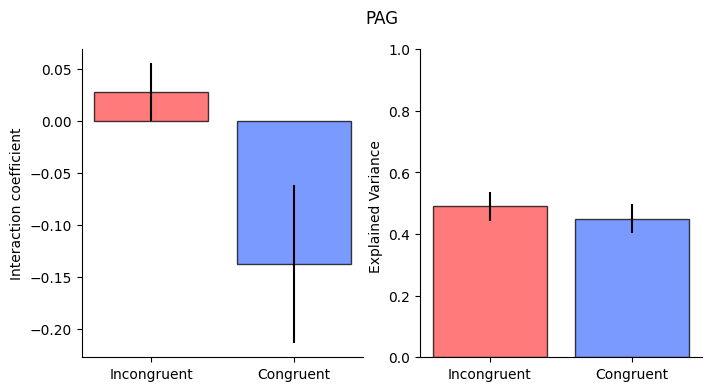

In [49]:
region_name = filename.rsplit("_stim_")[0].rsplit("_decomposition_")[-1]
icm, cm, sems = given_region_coeff_statistics(
    data_region=data_x, region=region_name, plotting=True
)

In [ ]:
    icm.shape

(8, 3)

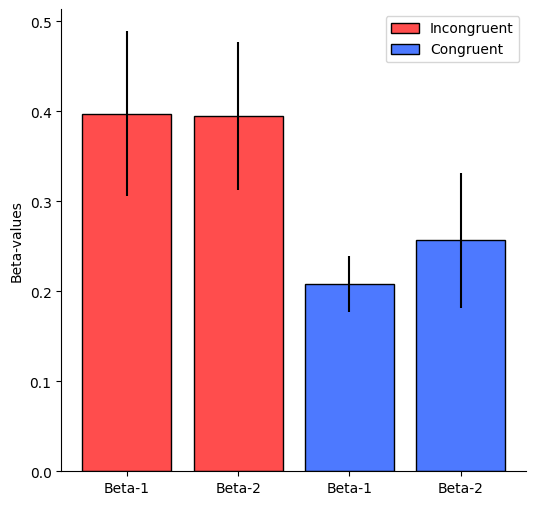

In [67]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.bar(
    np.arange(2),
    [np.mean(icm[:, 0]), np.mean(icm[:, 1])],
    yerr=[np.std(icm[:, 0]) / np.sqrt(len(icm)), np.std(icm[:, 1]) / np.sqrt(len(icm))],
    color=color[0],
    edgecolor="k",
    label="Incongruent",
)

ax.bar(
    np.arange(2) + 2,
    [np.mean(cm[:, 0]), np.mean(cm[:, 1])],
    yerr=[np.std(cm[:, 0]) / np.sqrt(len(cm)), np.std(cm[:, 1]) / np.sqrt(len(cm))],
    color=color[1],
    edgecolor="k",
    label="Congruent",
)
sns.despine()
ax.set_xticks(np.arange(4), ["Beta-1", "Beta-2", "Beta-1", "Beta-2"])
ax.set_ylabel("Beta-values")
ax.legend()